In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import astropy.units as u

In [2]:
ten_hertz_pd_data = pd.read_csv('/home/leoseen/aos_773/ps3data/PS3_10Hz_20140713.csv')
one_minute_pd_data = pd.read_csv('/home/leoseen/aos_773/ps3data/PS3_1minute_20140713.csv')
one_minute_pd_data = one_minute_pd_data.replace(-9999, np.nan)
thirty_minute_pd_data = pd.read_csv('/home/leoseen/aos_773/ps3data/PS3_30minute_20140713.csv')
thirty_minute_pd_data = thirty_minute_pd_data.replace(-9999, np.nan)

In [3]:
class get_data_information:
    def __init__(self, pd_data):
        self.hour = np.array(pd_data['Hr'])*u.hour
        self.min = np.array(pd_data['Min'])*u.minute
        if 'Sec' in pd_data.columns:
            self.second = np.array(pd_data['Sec'])*u.second
            self.total_time = (self.hour+self.min+self.second).to(u.second)
        else:
            self.total_time = (self.hour+self.min).to(u.second)
        pd_data['total_time'] = np.array(self.total_time)
        self.pd_data = pd_data

class get_select_data_information:
    def __init__(self, pd_data):
        self.pd_data = pd_data
        first_row = pd_data.iloc[0]
        self.pressure = np.array(pd_data['Pressure_kPa'])*u.kPa
        if 'Sec' in pd_data.columns:
            self.start_time = (np.array(first_row['Hr'])*u.hour + np.array(first_row['Min'])*u.minute + np.array(first_row['Sec'])*u.second).to(u.hour)
            self.ux = np.array(pd_data['Ux_ms-1'])*u.m/u.second
            self.uy = np.array(pd_data['Uy_ms-1'])*u.m/u.second
            self.uz = np.array(pd_data['Uz_ms-1'])*u.m/u.second
            self.Ts_virtual = np.array(pd_data['Ts_degreesC'])*u.deg_C
            self.CO2_g = np.array(pd_data['CO2_mgm-3'])*u.mg/(u.m*u.m*u.m)
            self.CO2_umol = np.array(self.CO2_g)*22.727*u.umol/(u.m*u.m*u.m)
            self.H2O = np.array(pd_data['H2O_gm-3'])*u.g/(u.m*u.m*u.m)
        else:
            self.start_time = (np.array(first_row['Hr'])*u.hour + np.array(first_row['Min'])*u.minute).to(u.hour)
            self.sw_up = np.array(pd_data['SW_up_Wm-2'])*u.W/(u.m*u.m)
            self.lw_up = np.array(pd_data['LW_up_Wm-2'])*u.W/(u.m*u.m)
            self.sw_down = np.array(pd_data['SW_down_Wm-2'])*u.W/(u.m*u.m)
            self.lw_down = np.array(pd_data['LW_down_Wm-2'])*u.W/(u.m*u.m)
            self.par = np.array(pd_data['PAR_umolm-2s-1'])*u.umol/(u.m*u.m*u.second)
            self.AirT = np.array(pd_data['AirT_degreesC'])*u.deg_C
            self.rh = np.array(pd_data['RH_%'])
            self.accum_precip = np.array(pd_data['AccumlatedPrecip_mm'])*u.mm
    
    def get_time_avg_info(self):
        if 'Sec' in self.pd_data.columns:
            self.mean_virtual_temp = np.mean(self.Ts_virtual)
            self.mean_CO2_umol = np.mean(self.CO2_umol)
            self.mean_H2O = np.mean(self.H2O)
            self.mean_CO2_MR = (np.array(self.mean_CO2_umol)*0.02896/(1.2))
            self.mean_SH = self.mean_H2O/(1.2*u.kg/(u.m*u.m*u.m))
            self.mean_temp = self.mean_virtual_temp.to(u.K, equivalencies=u.temperature())/(1+0.61*self.mean_SH/1000)
            self.mean_U = np.mean(self.ux)
            self.mean_V = np.mean(self.uy)
            self.mean_W = np.mean(self.uz)
            theta = np.arcsin(self.mean_W/(np.sqrt(self.mean_U**2+self.mean_V**2+self.mean_W**2)))
            phi = np.arcsin(self.mean_V/(np.sqrt(self.mean_U**2+self.mean_V**2)))
            if (self.mean_U<0) and (self.mean_V<0):
                phi = -np.pi*u.rad-phi
            elif (self.mean_U<0) and (self.mean_V>0):
                phi = np.pi*u.rad-phi
            self.Ur = np.cos(theta)*np.cos(phi)*self.ux+np.cos(theta)*np.sin(phi)*self.uy+np.sin(theta)*self.uz
            self.Vr = -np.sin(phi)*self.ux+np.cos(phi)*self.uy
            self.Wr = -np.sin(theta)*np.cos(phi)*self.ux-np.sin(theta)*np.sin(phi)*self.uy+np.cos(theta)*self.uz
            self.mean_WS = np.sqrt(self.mean_U**2+self.mean_V**2)
            self.mean_WD = ((189*u.deg+np.arctan(self.mean_V/self.mean_U)).to(u.deg)+360*u.deg)%(360*u.deg)
            self.up = self.Ur-np.mean(self.Ur)
            self.vp = self.Vr-np.mean(self.Vr)
            self.wp = self.Wr-np.mean(self.Wr)
            self.tsp = self.Ts_virtual - self.mean_virtual_temp
            self.cp = self.CO2_umol - self.mean_CO2_umol
            self.qp = self.H2O - self.mean_H2O
        else:
            self.mean_Rnet = np.nanmean(self.lw_down+self.sw_down-self.lw_up-self.sw_up)
            self.mean_AirT = np.nanmean(self.AirT)
            self.mean_par = np.nanmean(self.par)
        self.mean_pressure = np.nanmean(self.pressure)
    
    def get_time_avg_info_extra(self):
        self.cov_wp_tsp = np.cov([self.wp,self.tsp])[0][1]
        if len(self.shift_cp)!=len(self.wp):
            self.cov_wp_shift_qp = np.cov([self.wp[:-1],self.shift_qp])[0][1]
            self.cov_wp_shift_cp = np.cov([self.wp[:-1],self.shift_cp])[0][1]
        else:
            self.cov_wp_shift_qp = np.cov([self.wp,self.shift_qp])[0][1]
            self.cov_wp_shift_cp = np.cov([self.wp,self.shift_cp])[0][1]
        self.cov_wp_up = np.cov([self.wp,self.up])[0][1]
        self.cov_wp_vp = np.cov([self.wp,self.vp])[0][1]

        self.var_wp = np.cov([self.wp,self.wp])[0][0]
        self.var_up = np.cov([self.up,self.up])[0][0]
        self.var_vp = np.cov([self.vp,self.vp])[0][0]
        self.var_shift_cp = np.cov([self.shift_cp,self.shift_cp])[0][0]
        self.var_shift_qp = np.cov([self.shift_qp,self.shift_qp])[0][0]
        self.var_tsp = np.cov([self.tsp,self.tsp])[0][0]

        # It looks like in the worksheet that the constants are used for unit conversions. Can't really figure those out so 
        # I just got rid of the units for most of the variables. 
        term_1 = (1.6077*np.array(self.cov_wp_shift_qp*self.mean_CO2_umol))/(1000*1.2*(1+1.6077*self.mean_SH.to(u.kg/u.kg)))
        term_2 = (1+1.6077*np.array(self.mean_H2O)/(1000*1.2))*np.array(self.cov_wp_tsp*self.mean_CO2_umol)/np.array(self.mean_temp)
        self.C_flux = self.cov_wp_shift_cp+term_1+term_2
        term_1 = 1.6077*np.array(self.cov_wp_shift_qp*self.mean_H2O)/(1000*1.2)
        term_2 = (1+1.6077*np.array(self.mean_H2O)/(1000*1.2))*np.array(self.cov_wp_tsp*self.mean_H2O)/np.array(self.mean_temp)
        self.Q_flux = self.cov_wp_shift_qp+term_1+term_2
        
        # All the np.arrays are to get rid of units. If we knew the exact units of everything, this would be much easier
        self.B = 1004*1.2*np.array(self.cov_wp_tsp)
        self.H = 1004*1.2*(np.array(self.cov_wp_tsp)-0.61*np.array(self.mean_temp*self.Q_flux)/1000)
        self.Le = 2.5e6*1.2*np.array(self.Q_flux)/1000
        self.ustar = (np.array(self.cov_wp_up)**2+np.array(self.cov_wp_vp)**2)**(1/4)
        self.TKE = np.array(0.5*(self.var_up**2+self.var_vp**2+self.var_wp**2))
        self.L = np.array(-self.ustar**3*(self.mean_temp.to(u.K, equivalencies=u.temperature()))/(0.4*9.8*self.cov_wp_tsp))
        self.Bowen = np.array(self.H/self.Le)

In [4]:
ten_hertz_data = get_data_information(ten_hertz_pd_data)
one_minute_data = get_data_information(one_minute_pd_data)

## Ten Hertz

In [5]:
avg_time = 1800*u.second
avg_time = avg_time.to(u.s)

time_avg_idx = np.where(ten_hertz_data.total_time%avg_time == 0, 1, 0).nonzero()[0]
time_avg_data_ten_hertz = []
for i in range(len(time_avg_idx)):
    if i == len(time_avg_idx)-1:
        selected_data = get_select_data_information(ten_hertz_data.pd_data.iloc[time_avg_idx[i]:])
    else:
        selected_data = get_select_data_information(ten_hertz_data.pd_data.iloc[time_avg_idx[i]:time_avg_idx[i+1]])
    selected_data.get_time_avg_info()
    time_avg_data_ten_hertz.append(selected_data)

In [6]:
shift_qp = []
shift_cp = []
for value in time_avg_data_ten_hertz:
    shift_qp.append(value.qp)
    shift_cp.append(value.cp)
shift_qp = np.concatenate(shift_qp)[1:]
shift_cp = np.concatenate(shift_cp)[1:]

In [7]:
final_data = []
for i, value in enumerate(time_avg_data_ten_hertz):
    if i == len(time_avg_idx)-1:
        value.shift_qp = shift_qp[time_avg_idx[i]:]
        value.shift_cp = shift_cp[time_avg_idx[i]:]
    else:
        value.shift_qp = shift_qp[time_avg_idx[i]:time_avg_idx[i+1]]
        value.shift_cp = shift_cp[time_avg_idx[i]:time_avg_idx[i+1]]
    value.get_time_avg_info_extra()
    final_data.append(value)

##  One Minute

In [8]:
avg_time = 1800*u.second
avg_time = avg_time.to(u.s)

time_avg_idx = np.where(one_minute_data.total_time%avg_time == 0, 1, 0).nonzero()[0]
time_avg_data_one_min = []
for i in range(len(time_avg_idx)):
    if i == len(time_avg_idx)-1:
        selected_data = get_select_data_information(one_minute_data.pd_data.iloc[time_avg_idx[i]:])
    else:
        selected_data = get_select_data_information(one_minute_data.pd_data.iloc[time_avg_idx[i]:time_avg_idx[i+1]])
    selected_data.get_time_avg_info()
    time_avg_data_one_min.append(selected_data)

# Format

In [9]:
class format_csv:
    def __init__(self, object):
        self.Hour = object.start_time
        self.AirPressure_mean = object.mean_pressure
        if 'Sec' in object.pd_data.columns:
            self.Ts_mean = object.mean_virtual_temp
            self.T_mean = object.mean_temp
            self.CO2_mean = object.mean_CO2_umol
            self.H2O_mean = object.mean_H2O
            self.SH = object.mean_SH
            self.WS = object.mean_WS
            self.WD = object.mean_WD
            self.C_flux = object.C_flux
            self.Q_flux = object.Q_flux
            self.B = object.B*u.W/(u.m*u.m)
            self.H = object.H*u.W/(u.m*u.m)
            self.Le = object.Le*u.W/(u.m*u.m)
            self.ustar = object.ustar*u.m/u.s
            self.TKE = object.TKE*(u.m*u.m/(u.s*u.s))
            self.L = object.L*u.m
            self.Bowen =  object.Bowen
            self.var_wp = object.var_wp*(u.m*u.m/(u.s*u.s))
            self.var_up = object.var_up*(u.m*u.m/(u.s*u.s))
            self.var_vp = object.var_vp*(u.m*u.m/(u.s*u.s))
            self.var_cp = object.var_shift_cp
            self.var_qp = object.var_shift_qp
            self.var_tp = object.var_tsp*u.deg_C*u.deg_C
        else:
            self.AirT_mean = object.mean_AirT
            self.PAR = object.mean_par
            self.Rnet = object.mean_Rnet

In [10]:
final_data_format_ten_hertz = []
final_data_format_one_min = []
for obj in final_data:
    final_data_format_ten_hertz.append(format_csv(obj))
for obj in time_avg_data_one_min:
    final_data_format_one_min.append(format_csv(obj))

In [11]:
final_data_pd_ten_hertz = []
final_data_pd_one_min = []
for obj in final_data_format_ten_hertz:
    final_data_pd_ten_hertz.append(pd.DataFrame([obj.__dict__]))
for obj in final_data_format_one_min:
    final_data_pd_one_min.append(pd.DataFrame([obj.__dict__]))

In [12]:
final_data_pd_ten_hertz = pd.concat(final_data_pd_ten_hertz)
final_data_pd_one_min = pd.concat(final_data_pd_one_min)

In [13]:
ultimate_data = final_data_pd_ten_hertz.merge(final_data_pd_one_min, how = 'inner', on = ['Hour'])

In [76]:
print(ultimate_data.keys())

Index(['Hour', 'AirPressure_mean_x', 'Ts_mean', 'T_mean', 'CO2_mean',
       'H2O_mean', 'SH', 'WS', 'WD', 'C_flux', 'Q_flux', 'B', 'H', 'Le',
       'ustar', 'TKE', 'L', 'Bowen', 'var_wp', 'var_up', 'var_vp', 'var_cp',
       'var_qp', 'var_tp', 'AirPressure_mean_y', 'AirT_mean', 'PAR', 'Rnet'],
      dtype='object')


In [78]:
ultimate_data.to_csv('/home/leoseen/aos_773/ps3data/PS3_final_data.csv')

# Make Plots

In [14]:
print(ultimate_data.keys())

Index(['Hour', 'AirPressure_mean_x', 'Ts_mean', 'T_mean', 'CO2_mean',
       'H2O_mean', 'SH', 'WS', 'WD', 'C_flux', 'Q_flux', 'B', 'H', 'Le',
       'ustar', 'TKE', 'L', 'Bowen', 'var_wp', 'var_up', 'var_vp', 'var_cp',
       'var_qp', 'var_tp', 'AirPressure_mean_y', 'AirT_mean', 'PAR', 'Rnet'],
      dtype='object')


In [ ]:
variables_of_interest = ['CO2_mean',
                         'H2O_mean',
                         'SH',
                         'Le',
                         'ustar',
                         'TKE',
                         'L',
                         'var_up',
                         'var_wp',
                         'var_tp',
                         'Rnet', 
                         'H']

subset_df = ultimate_data[variables_of_interest]

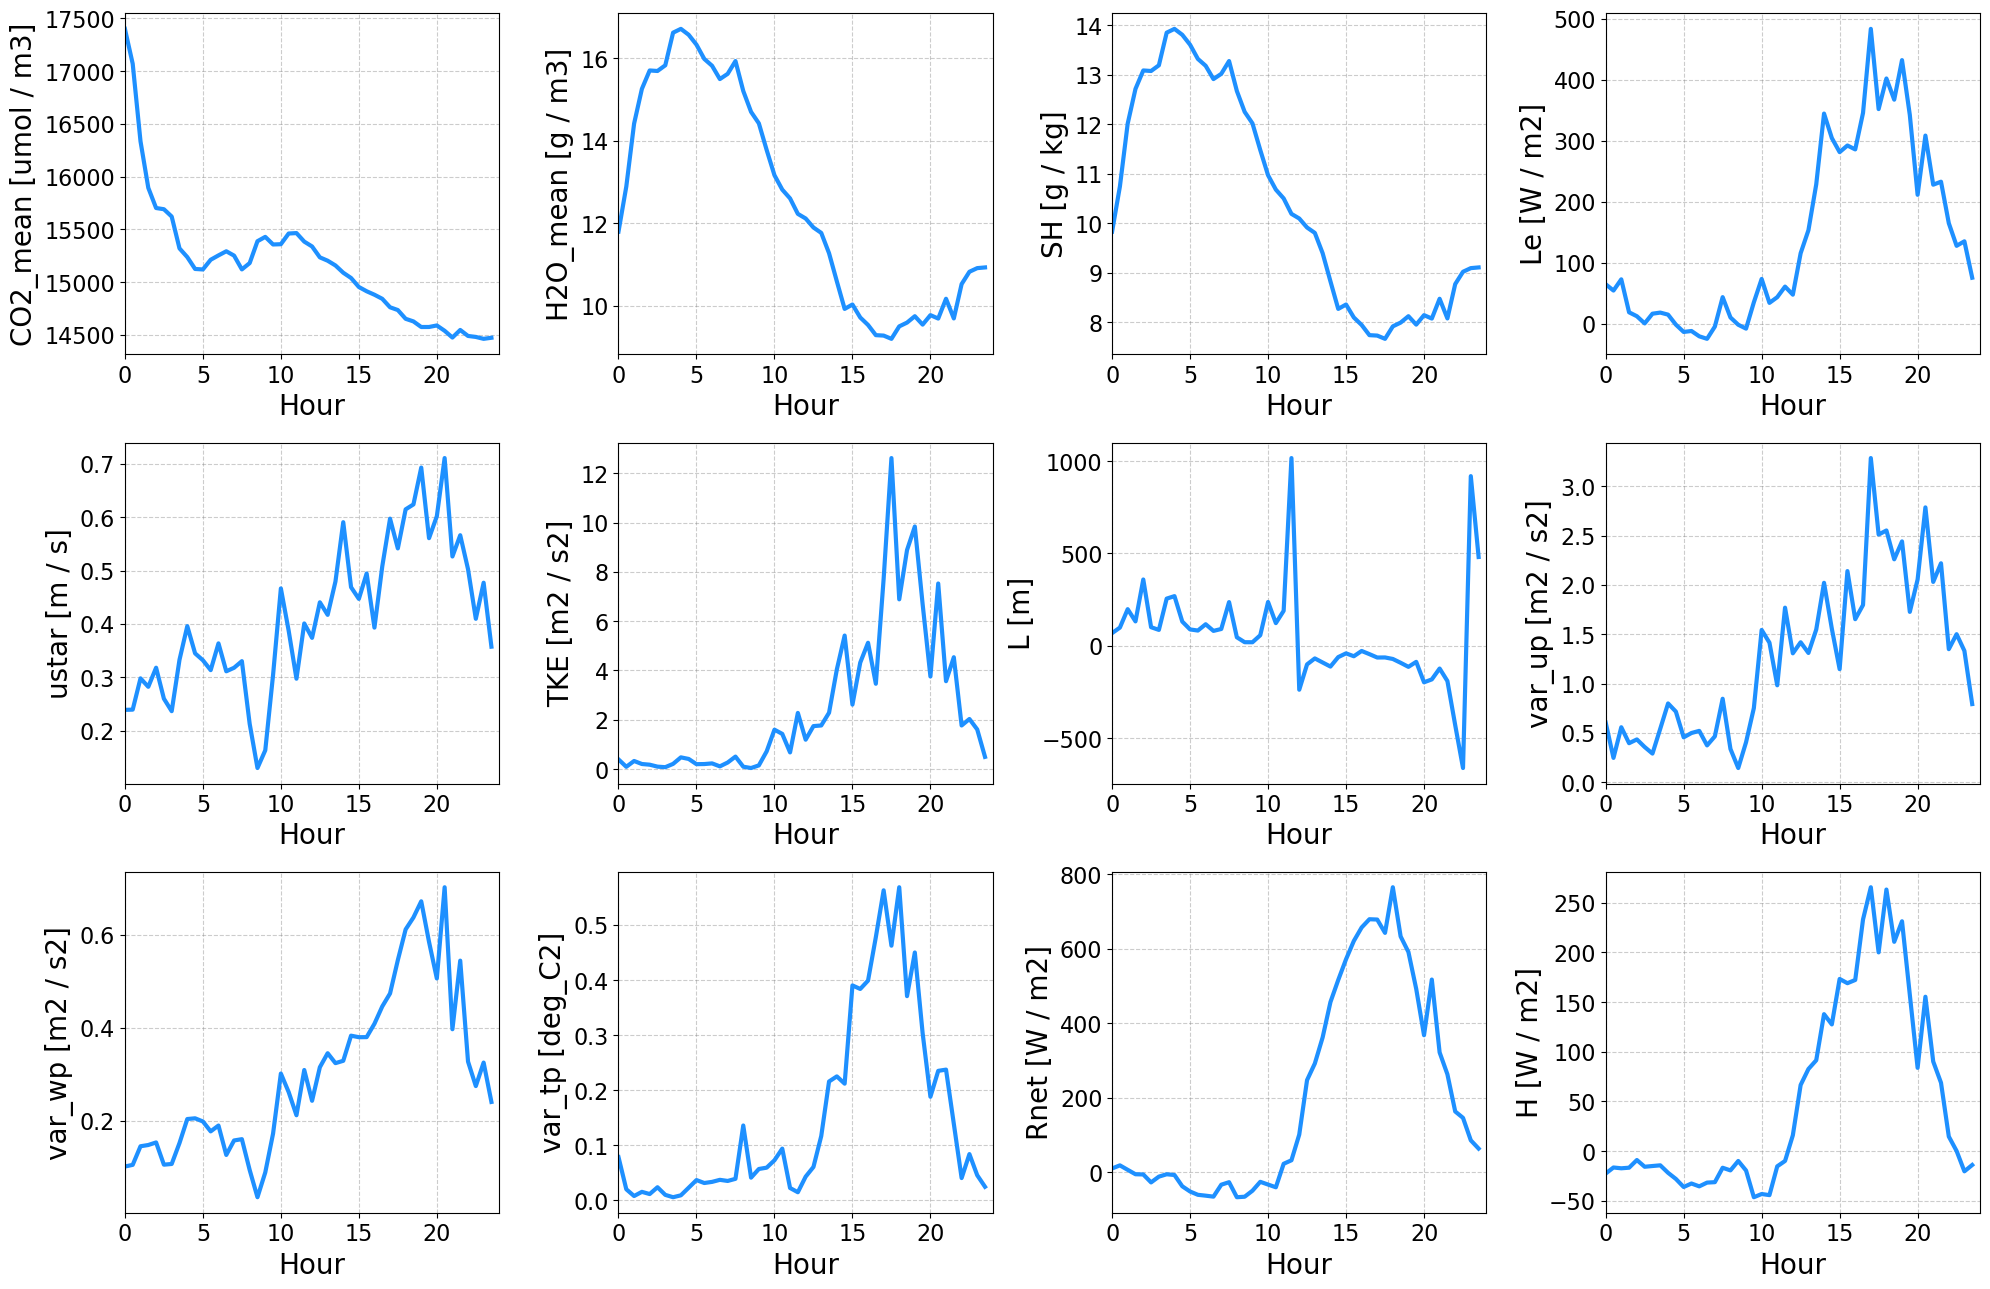

In [16]:
hour = ultimate_data['Hour'].apply(lambda x: x.value)
fig, axs = plt.subplots(3,4, figsize = (20,13))
j, i = 0, 0 
for column, values in subset_df.items():
    try:
        unit = values.iloc[0].unit
        values = values.apply(lambda x: x.value)
    except:
        unit = None
        print(column)
    axs[j][i].plot(hour, values, linewidth = 3, color = 'dodgerblue')
    axs[j][i].set_xlim(0,24)
    axs[j][i].tick_params(axis = 'both', labelsize = 16)
    axs[j][i].set_xlabel(r'Hour', fontsize = 20)
    axs[j][i].grid(alpha = 0.4, color = 'grey', linestyle = '--')
    if unit is None:
        axs[j][i].set_ylabel(f'No Units', fontsize = 20)
    else:
        axs[j][i].set_ylabel(f'{column} [{unit}]', fontsize = 20)

    i+=1
    if i%4 == 0:
        j+=1
        i = 0
fig.tight_layout()
# CO2_mean = ultimate_data['CO2_mean'].apply(lambda x: x.value)
# H2O_mean = ultimate_data['H2O_mean'].apply(lambda x: x.value)

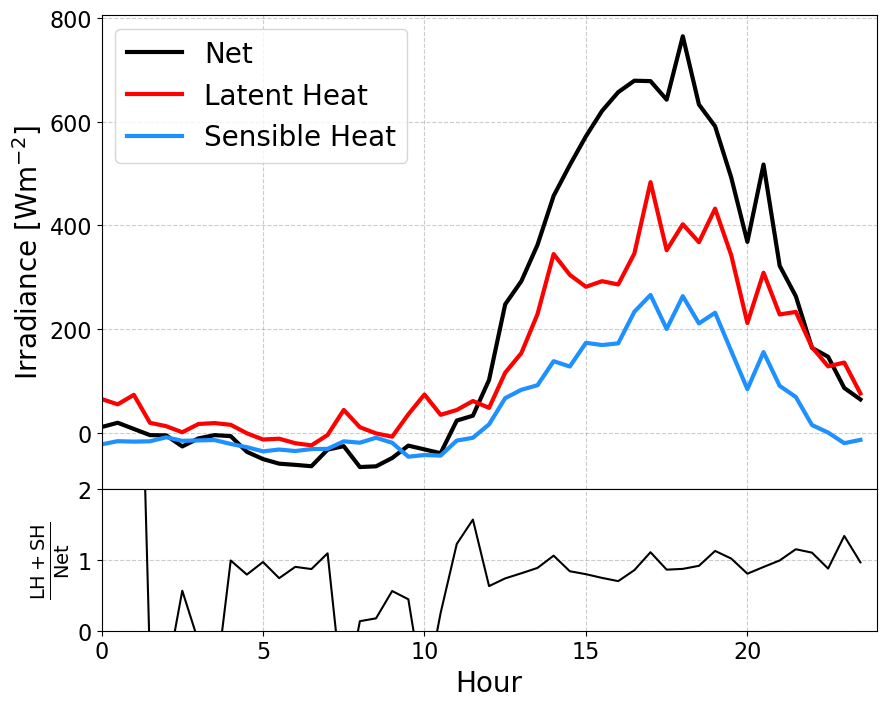

In [17]:
Rnet = subset_df['Rnet'].apply(lambda x: x.value)
Le = subset_df['Le'].apply(lambda x: x.value)
H = subset_df['H'].apply(lambda x: x.value)

fig, ax = plt.subplots(2,1,figsize = (10,8), gridspec_kw={'height_ratios': [10, 3]}, sharex = True)
ax[0].plot(hour, Rnet, linewidth = 3, color = 'black', label = 'Net')
ax[0].plot(hour, Le, linewidth = 3, color = 'red', label = 'Latent Heat')
ax[0].plot(hour, H, linewidth = 3, color = 'dodgerblue', label = 'Sensible Heat')
ax[0].set_xlim(0,24)
ax[0].tick_params(axis = 'both', labelsize = 16)
ax[1].set_xlabel(r'Hour', fontsize = 20)
ax[0].set_ylabel(r'Irradiance [Wm$^{-2}$]', fontsize = 20)
ax[0].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[1].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[0].legend(fontsize = 20)

ax[1].plot(hour, (Le+H)/Rnet, color = 'black')
ax[1].set_ylim(0,2)
ax[1].set_ylabel(r'$\frac{\mathrm{LH}+\mathrm{SH}}{\mathrm{Net}}$', fontsize = 20)
fig.subplots_adjust(hspace=0)
ax[1].tick_params(axis = 'both', labelsize = 16)

In [46]:
for column, values in subset_df.items():
    subset_df[column] = values.apply(lambda x:x.value)

/tmp/ipykernel_9191/1948555290.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df[column] = values.apply(lambda x:x.value)


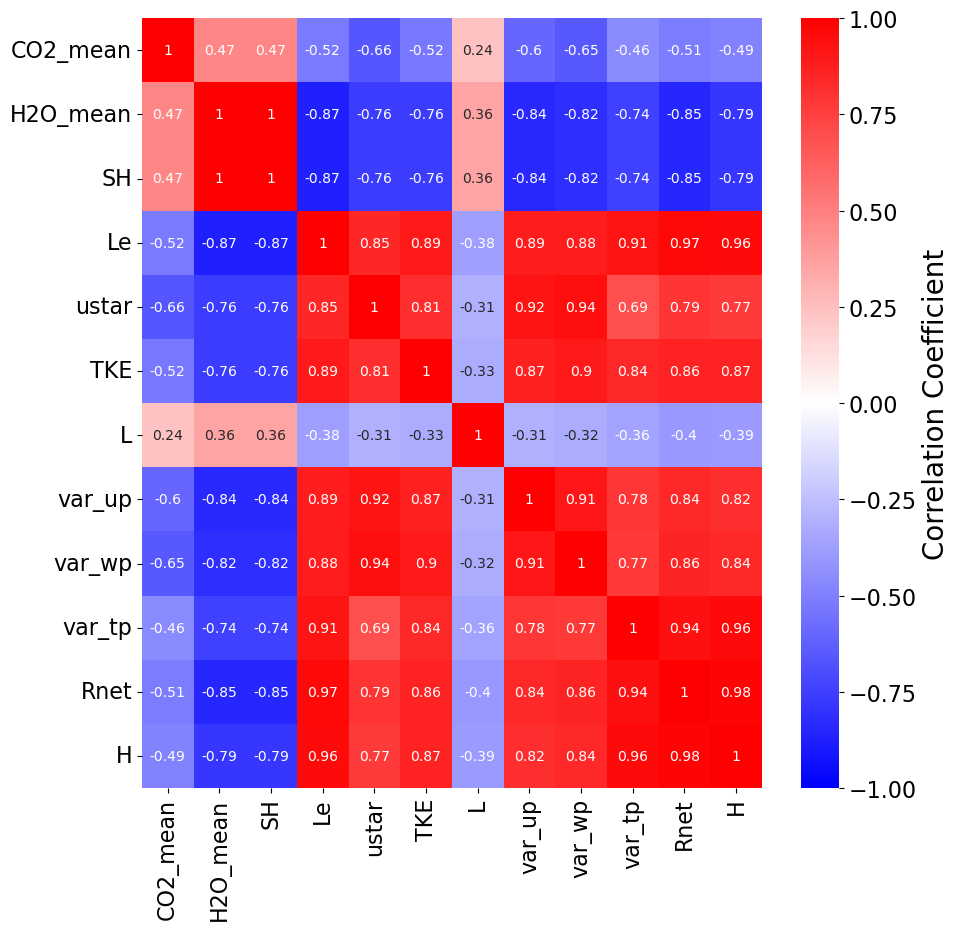

In [70]:
correlation_matrix = subset_df.corr()
fig, ax = plt.subplots(1,1, figsize = (10,10))
sns.heatmap(correlation_matrix, cmap = 'bwr', annot=True, ax= ax, center = 0, vmin = -1, vmax = 1)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label('Correlation Coefficient', fontsize=20)
ax.tick_params(axis = 'both', labelsize = 16)

# Cross-Check with 30 Minute data

In [18]:
print(thirty_minute_pd_data.keys())

Index(['Hr', 'SW_down_Wm-2', 'SW_up_Wm-2', 'LW_down_Wm-2', 'LW_up_Wm-2',
       'NetRad_Wm-2', 'PAR_umolm-2s-1', 'AirP_kPa', 'AirTemp_degreesC', 'RH_%',
       'AccumulatedPrecip_mm', 'WindSpeed_ms-1', 'WindDirection_degrees',
       'CO2_ppm', 'H2O_gkg-1', 'CO2flux_umolm-2s-1', 'HLatentHeatFlux_Wm-2',
       'SensibleHeatFlux_Wm-2', 'u*_ms-1', 'tke_m2s2', 'MO_Length_m',
       'Rho_kgm-3', 'Cp_JK-1kg-1'],
      dtype='object')


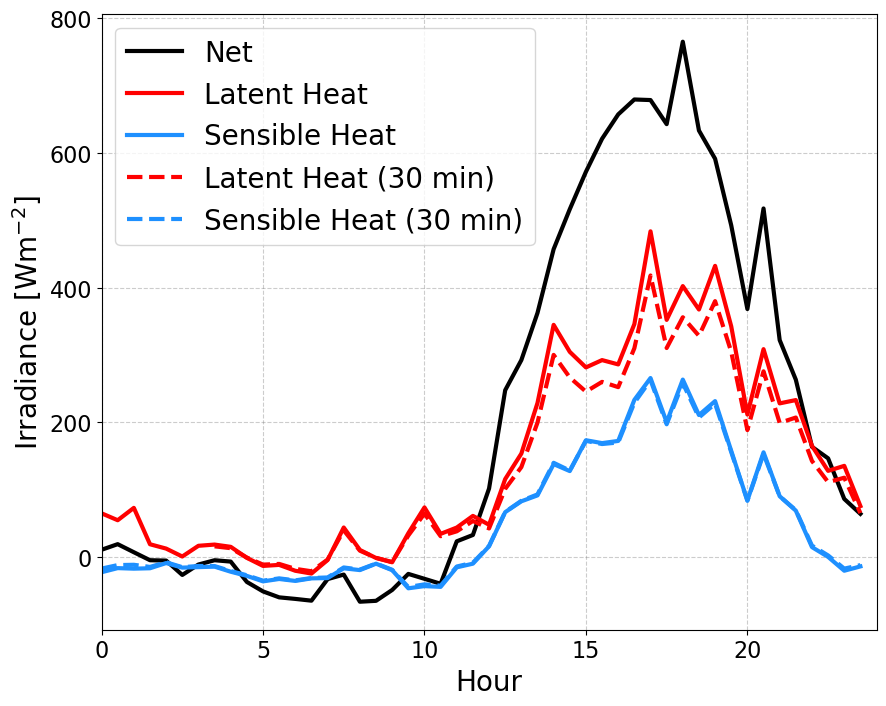

In [69]:
fig, ax = plt.subplots(1,1,figsize = (10,8))
ax.plot(hour, Rnet, linewidth = 3, color = 'black', label = 'Net')
ax.plot(hour, Le, linewidth = 3, color = 'red', label = 'Latent Heat')
ax.plot(hour, H, linewidth = 3, color = 'dodgerblue', label = 'Sensible Heat')
ax.plot(thirty_minute_pd_data['Hr'], thirty_minute_pd_data['HLatentHeatFlux_Wm-2'], color = 'red', linestyle = '--', label = 'Latent Heat (30 min)', linewidth = 3)
ax.plot(thirty_minute_pd_data['Hr'], thirty_minute_pd_data['SensibleHeatFlux_Wm-2'], color = 'dodgerblue', linestyle = '--', label = 'Sensible Heat (30 min)', linewidth = 3)
ax.set_xlim(0,24)
ax.tick_params(axis = 'both', labelsize = 16)
ax.set_ylabel(r'Irradiance [Wm$^{-2}$]', fontsize = 20)
ax.grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax.set_xlabel('Hour', fontsize = 20)
ax.legend(fontsize = 20)